# MATH GR5360 Final Project — Notebook 1
## Data Loading & Statistical Tests

**Columbia University — Mathematical Methods in Financial Price Analysis**

**Group 1** — Primary: **TY** (10-Year US Treasury Futures) &nbsp;&nbsp;•&nbsp;&nbsp; Secondary: **BTC** (Bitcoin)

---

### Purpose

This notebook runs two market-inefficiency diagnostic tests on 5-minute bar data:

1. **Andrew Lo (Lo–MacKinlay, 1988) Variance Ratio Test** — checks whether $k$-period return variance grows linearly with $k$ (the random-walk null). Deviations indicate either momentum ($VR>1$) or mean-reversion ($VR<1$). Uses the heteroskedasticity-robust $Z_2^*$ statistic by default.
2. **Push–Response Test** — regresses forward ("response") returns on trailing ("push") returns to measure directional persistence across window pairs.

Toggle `MARKET_SELECT` in the config cell between `'TY'` and `'BTC'` to rerun the entire notebook for either market.

In [17]:
# ============================================================================
# MARKET SELECTOR — toggle between our primary and secondary market
# ============================================================================
MARKET_SELECT = 'TY'     # 'TY' (primary, 10-Year Treasury Futures) or 'BTC' (secondary)

In [18]:
# ============================================================================
# MARKET PARAMETERS DATABASE
# ============================================================================
# Values for the 18 course primary markets come from TF_Data.xls.
# BTC parameters reflect the CME Bitcoin futures contract (BTC, 5 BTC/contract,
# $5 per point, ~$50 round-turn slippage on 5-min bars).

MARKET_DATABASE = {
    # Ticker: (Name, Exchange, PV, Slippage, TickValue, PV_Multiplier)
    'BO': ('Soybean Oil',      'CBOT-CME',       600,  39,     6,     1),
    'DX': ('Dollar Index',     'NYBOT-ICE',      1000, 16.5,   5,     1),
    'HG': ('Copper',           'COMEX-NYMEX-CME', 250, 59.25, 12.5,   1),
    'HO': ('Heating Oil',      'NYMEX-CME',      420,  70.2,   4.2, 100),
    'JO': ('Orange Juice',     'NYBOT-ICE',      150, 183,     7.5,   1),
    'JY': ('Japanese Yen',     'CME',            1250, 53,     6.25,100),
    'SY': ('Soybeans',         'CBOT-CME',        50,  35.5,  12.5,   1),
    'SB': ('Sugar #11',        'NYBOT-ICE',     1120,  56.76, 11.2,   1),
    'SF': ('Swiss Franc',      'CME',           1250,  25.5,  12.5, 100),
    'TU': ('2-Year Treasury',  'CBOT-CME',      2000,  18.625,15.625, 1),
    'TY': ('10-Year Treasury', 'CBOT-CME',      1000,  18.625,15.625, 1),
    'WC': ('Wheat',            'CBOT-CME',        50,  30.5,  12.5,   1),
    'SM': ('Soybean Meal',     'CBOT-CME',       100,  57,    10,     1),
    'CC': ('Cocoa',            'NYBOT-ICE',       10, 103,    10,     1),
    'BZ': ('Schatz',           'EUREX',         1000,  10.5,   5,     1),
    'CL': ('Crude Oil WTI',    'NYMEX-CME',     1000,  46,    10,     1),
    'GC': ('Gold 100oz',       'COMEX-NYMEX-CME',100,  65,    10,     1),
    'SV': ('Silver',           'COMEX-NYMEX-CME',5000,243,    25,  0.01),
    # --- Secondary (BTC). CME Bitcoin futures conventions. --------------------
    'BTC':('Bitcoin',          'CME / Spot',       5,  50,    25,     1),
}

In [19]:
# ============================================================================
# AUTO-CONFIGURE MARKET
# ============================================================================
# Fallback if cell-1 wasn't executed yet — keeps the notebook robust to
# out-of-order runs (e.g. "Run All Below" from this cell).
if 'MARKET_SELECT' not in globals():
    MARKET_SELECT = 'TY'

assert MARKET_SELECT in MARKET_DATABASE, f"Unknown market: {MARKET_SELECT}"

TICKER = MARKET_SELECT
_info = MARKET_DATABASE[TICKER]

MARKET = {
    'ticker':        TICKER,
    'name':          _info[0],
    'exchange':      _info[1],
    'PV':            _info[2],   # Point value ($ per 1-point move per contract)
    'slpg':          _info[3],   # Round-turn slippage, USD
    'tick_value':    _info[4],
    'pv_multiplier': _info[5],
    'E0':            100000,     # Initial equity
}

DATA_FILE = f'../data/{TICKER}-5minHLV.csv'

print("=" * 72)
print(f"MARKET CONFIGURATION: {MARKET['ticker']} — {MARKET['name']}")
print("=" * 72)
print(f"Exchange:          {MARKET['exchange']}")
print(f"Point Value (PV):  ${MARKET['PV']:,}")
print(f"Slippage (RT):     ${MARKET['slpg']}")
print(f"Tick Value:        ${MARKET['tick_value']}")
print(f"Initial Equity:    ${MARKET['E0']:,}")
print(f"Data file:         {DATA_FILE}")
print("=" * 72)

MARKET CONFIGURATION: TY — 10-Year Treasury
Exchange:          CBOT-CME
Point Value (PV):  $1,000
Slippage (RT):     $18.625
Tick Value:        $15.625
Initial Equity:    $100,000
Data file:         ../data/TY-5minHLV.csv


In [20]:
# ============================================================================
# IMPORTS + COLUMBIA THEME
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from numba import jit
from tqdm.notebook import tqdm
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------------
# Columbia University visual identity palette
# ------------------------------------------------------------------
COLUMBIA_BLUE   = '#B9D9EB'   # Columbia Blue (primary)
COLUMBIA_CORE   = '#75AADB'   # Core Columbia Blue
COLUMBIA_NAVY   = '#012169'   # Columbia Navy
COLUMBIA_DARK   = '#1D4F91'   # Deep Blue
COLUMBIA_ACCENT = '#C4D8E2'   # Pale blue accent
COLUMBIA_GREY   = '#4B4B4B'   # Graphite
COLUMBIA_WARM   = '#E08119'   # Accent warm (only for contrast highlights)
COLUMBIA_OFFWHT = '#F5F5F0'

COLUMBIA_CMAP = LinearSegmentedColormap.from_list(
    'columbia', [COLUMBIA_NAVY, COLUMBIA_DARK, COLUMBIA_CORE, COLUMBIA_BLUE, '#FFFFFF']
)
COLUMBIA_DIVERGING = LinearSegmentedColormap.from_list(
    'columbia_div', ['#8B0000', '#CC5500', '#FFFFFF', COLUMBIA_CORE, COLUMBIA_NAVY]
)

mpl.rcParams.update({
    'figure.figsize':      (14, 6),
    'figure.facecolor':    'white',
    'axes.facecolor':      'white',
    'axes.edgecolor':      COLUMBIA_NAVY,
    'axes.labelcolor':     COLUMBIA_NAVY,
    'axes.titlecolor':     COLUMBIA_NAVY,
    'axes.titleweight':    'bold',
    'axes.titlesize':      13,
    'axes.labelsize':      11,
    'axes.grid':           True,
    'grid.color':          COLUMBIA_ACCENT,
    'grid.alpha':          0.55,
    'grid.linewidth':      0.7,
    'xtick.color':         COLUMBIA_NAVY,
    'ytick.color':         COLUMBIA_NAVY,
    'legend.frameon':      True,
    'legend.edgecolor':    COLUMBIA_NAVY,
    'lines.linewidth':     1.3,
    'font.size':           11,
    'font.family':         'DejaVu Sans',
})

print(f"Notebook started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Theme: Columbia Blue  |  Market: {MARKET['ticker']} ({MARKET['name']})")

Notebook started: 2026-04-17 01:36:11
Theme: Columbia Blue  |  Market: TY (10-Year Treasury)


---
## 2. Data Loading

In [21]:
def load_ohlc_data(filepath):
    """
    Load 5-minute OHLC data from CSV file.
    Compatible with ezread.m format.
    """
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip().str.lower()
    print(f"Columns found: {list(df.columns)}")
    
    # Parse datetime
    if 'date' in df.columns and 'time' in df.columns:
        df['datetime'] = pd.to_datetime(
            df['date'].astype(str) + ' ' + df['time'].astype(str),
            format='mixed'
        )
    elif 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
    else:
        df['datetime'] = pd.to_datetime(df.iloc[:, 0])
    
    df.set_index('datetime', inplace=True)
    df.sort_index(inplace=True)
    
    # Standardize column names
    rename_map = {}
    for col in df.columns:
        cl = col.lower()
        if 'open' in cl: rename_map[col] = 'Open'
        elif 'high' in cl: rename_map[col] = 'High'
        elif 'low' in cl: rename_map[col] = 'Low'
        elif 'close' in cl: rename_map[col] = 'Close'
        elif 'vol' in cl: rename_map[col] = 'Volume'
    
    df.rename(columns=rename_map, inplace=True)
    cols = [c for c in ['Open', 'High', 'Low', 'Close', 'Volume'] if c in df.columns]
    return df[cols].astype(float)


def validate_data(df):
    """Validate OHLC data integrity."""
    print("\n" + "=" * 60)
    print("DATA VALIDATION")
    print("=" * 60)
    print(f"Total bars: {len(df):,}")
    print(f"Date range: {df.index.min()} to {df.index.max()}")
    print(f"Duration: {(df.index.max() - df.index.min()).days / 365.25:.1f} years")
    
    # Check integrity
    issues = []
    if (df['High'] < df['Low']).any():
        issues.append(f"High < Low: {(df['High'] < df['Low']).sum()} bars")
    if (df['High'] < df['Open']).any() or (df['High'] < df['Close']).any():
        issues.append("High < Open or Close")
    
    if issues:
        print(f"\n⚠️ Issues: {issues}")
    else:
        print("\n✓ Data integrity OK")
    
    print(f"\nPrice range: {df['Close'].min():.4f} to {df['Close'].max():.4f}")
    return len(issues) == 0

In [22]:
# ============================================================================
# LOAD DATA  (falls back to synthetic series if CSV not found)
# ============================================================================
try:
    df = load_ohlc_data(DATA_FILE)
    validate_data(df)

except FileNotFoundError:
    print(f"⚠️ Data file not found: {DATA_FILE}")
    print(f"   Expected {TICKER}-5minHLV.csv in ../data/ — falling back to synthetic series.\n")

    # Synthetic series — different seed per ticker so outputs stay deterministic
    seed_map = {k: i for i, k in enumerate(MARKET_DATABASE.keys(), start=1)}
    np.random.seed(42 + seed_map[TICKER])
    n = 250_000
    dates = pd.date_range('2010-01-01', periods=n, freq='5min')

    start_prices = {
        'BO': 30, 'DX': 90, 'HG': 3, 'HO': 2, 'JO': 100, 'JY': 0.009,
        'SY': 900, 'SB': 15, 'SF': 1, 'TU': 105, 'TY': 115, 'WC': 500,
        'SM': 300, 'CC': 2500, 'BZ': 110, 'CL': 60, 'GC': 1300, 'SV': 15,
        'BTC': 20000,
    }
    start_price = start_prices.get(TICKER, 100)

    # BTC is more volatile than futures — bump vol accordingly
    base_sigma = 0.0015 if TICKER == 'BTC' else 0.0003
    returns = np.random.randn(n) * base_sigma
    trend = np.sin(np.linspace(0, 8 * np.pi, n)) * (base_sigma / 3)
    close = start_price * np.exp(np.cumsum(returns + trend))

    df = pd.DataFrame({
        'Open':  close * (1 + np.random.randn(n) * base_sigma / 3),
        'High':  close * (1 + np.abs(np.random.randn(n) * base_sigma)),
        'Low':   close * (1 - np.abs(np.random.randn(n) * base_sigma)),
        'Close': close,
    }, index=dates)
    df['High'] = df[['Open', 'High', 'Close']].max(axis=1)
    df['Low']  = df[['Open', 'Low',  'Close']].min(axis=1)

    print(f"✓ Generated {len(df):,} bars of synthetic data")
    validate_data(df)

Columns found: ['date', 'time', 'open', 'high', 'low', 'close', 'volume']

DATA VALIDATION
Total bars: 863,887
Date range: 1983-01-03 08:05:00 to 2026-04-10 14:00:00
Duration: 43.3 years

✓ Data integrity OK

Price range: 69.8125 to 140.4844


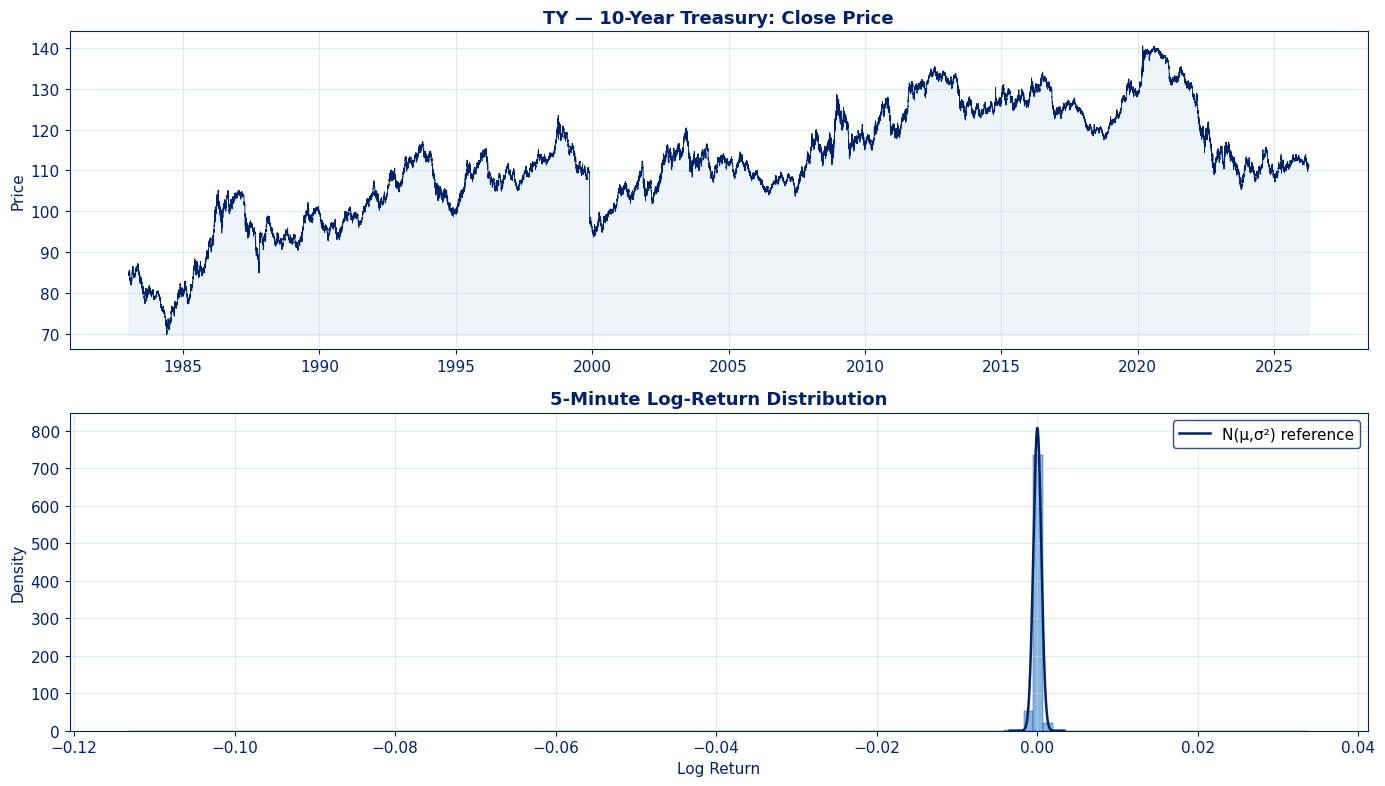


Returns summary  —  mean=+3.161e-07  std=0.00049  skew=-14.049  ex-kurt=+3324.511


In [23]:
# ============================================================================
# VISUALIZE PRICE + RETURNS DISTRIBUTION (Columbia theme)
# ============================================================================
returns = np.log(df['Close'] / df['Close'].shift(1)).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax1 = axes[0]
ax1.plot(df.index, df['Close'], color=COLUMBIA_NAVY, linewidth=0.6)
ax1.fill_between(df.index, df['Close'], df['Close'].min(),
                 color=COLUMBIA_BLUE, alpha=0.25)
ax1.set_title(f"{MARKET['ticker']} — {MARKET['name']}: Close Price")
ax1.set_ylabel('Price')

ax2 = axes[1]
ax2.hist(returns, bins=120, density=True, alpha=0.85,
         color=COLUMBIA_CORE, edgecolor=COLUMBIA_NAVY, linewidth=0.3)
# overlay a normal for reference
x = np.linspace(returns.quantile(0.001), returns.quantile(0.999), 400)
ax2.plot(x, stats.norm.pdf(x, returns.mean(), returns.std()),
         color=COLUMBIA_NAVY, linewidth=1.8, label='N(μ,σ²) reference')
ax2.set_title('5-Minute Log-Return Distribution')
ax2.set_xlabel('Log Return')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nReturns summary  —  mean={returns.mean():+.3e}  std={returns.std():.5f}"
      f"  skew={stats.skew(returns):+.3f}  ex-kurt={stats.kurtosis(returns):+.3f}")

---
## 3. Andrew Lo (Lo–MacKinlay 1988) Variance Ratio Test

For log-returns $r_t$, the $k$-period **variance ratio** is
$$VR(k) = \frac{\text{Var}(r_t^{(k)})}{k\,\text{Var}(r_t)}, \qquad r_t^{(k)} = \sum_{i=0}^{k-1} r_{t-i}.$$

Under the random-walk null, $VR(k)=1$ for all $k$. We use Lo–MacKinlay's overlapping-observation unbiased estimator and report both:

- **$Z_1$** (homoskedastic) and **$Z_2^*$** (heteroskedasticity-robust) asymptotic $\mathcal{N}(0,1)$ statistics,
- Interpretation: $VR(k)>1 \Rightarrow$ positive autocorrelation (**trend**); $VR(k)<1 \Rightarrow$ negative autocorrelation (**mean-reversion**).

In [24]:
def lo_mackinlay_vr(returns, k):
    """
    Lo–MacKinlay (1988) variance ratio test for k-period aggregation.

    Returns a dict containing:
        VR     : variance ratio estimate
        Z1     : homoskedastic z-statistic
        Z2     : heteroskedasticity-robust z-statistic (Lo-MacKinlay M2)
        p1, p2 : corresponding two-sided p-values against N(0,1)

    Uses overlapping k-period returns with the unbiased denominator
    m = k * (T - k + 1) * (1 - k/T) per Lo-MacKinlay (1988, eq. 10).
    """
    r = np.asarray(returns, dtype=np.float64)
    T = len(r)
    if T < k + 10 or k < 2:
        return {'VR': np.nan, 'Z1': np.nan, 'Z2': np.nan,
                'p1': np.nan, 'p2': np.nan}

    mu = r.mean()
    dev = r - mu
    sum_sq = np.sum(dev ** 2)

    # 1-period variance (unbiased)
    sigma2_1 = sum_sq / (T - 1)

    # k-period overlapping returns
    csum = np.concatenate(([0.0], np.cumsum(r)))
    ret_k = csum[k:] - csum[:-k]           # length T-k+1
    m = k * (T - k + 1) * (1 - k / T)
    sigma2_k = np.sum((ret_k - k * mu) ** 2) / m

    VR = sigma2_k / sigma2_1

    # --- Homoskedastic Z1 --------------------------------------------------
    phi = 2.0 * (2 * k - 1) * (k - 1) / (3.0 * k * T)
    Z1 = (VR - 1.0) / np.sqrt(phi)

    # --- Heteroskedasticity-robust Z2 (Lo-MacKinlay M2) --------------------
    # delta_j = T * sum_{t=j+1}^T (r_t-mu)^2 (r_{t-j}-mu)^2 / [sum (r_t-mu)^2]^2
    delta_var = 0.0
    dev_sq = dev ** 2
    denom = sum_sq ** 2
    for j in range(1, k):
        weight = 2.0 * (k - j) / k
        delta_j = T * np.sum(dev_sq[j:] * dev_sq[:-j]) / denom if denom > 0 else 0.0
        delta_var += (weight ** 2) * delta_j
    Z2 = (VR - 1.0) / np.sqrt(delta_var) if delta_var > 0 else np.nan

    p1 = 2.0 * (1.0 - stats.norm.cdf(abs(Z1)))
    p2 = 2.0 * (1.0 - stats.norm.cdf(abs(Z2))) if np.isfinite(Z2) else np.nan

    return {'VR': VR, 'Z1': Z1, 'Z2': Z2, 'p1': p1, 'p2': p2}


# Backwards-compatible alias
def variance_ratio_test(returns, k, robust=True):
    res = lo_mackinlay_vr(returns, k)
    return {
        'VR': res['VR'],
        'z_stat': res['Z2'] if robust else res['Z1'],
        'p_value': res['p2'] if robust else res['p1'],
    }

In [25]:
# ============================================================================
# RUN LO–MACKINLAY VARIANCE RATIO TESTS
# ============================================================================
returns_arr = np.log(df['Close'] / df['Close'].shift(1)).dropna().values

# k values expressed in 5-minute bars.  Covers 10min → ~40 trading days.
k_values = [2, 4, 8, 12, 24, 48, 78, 156, 312, 780, 1560, 3120]

def bars_to_time(k):
    mins = k * 5
    if mins < 60:    return f"{mins}min"
    if mins < 390:   return f"{mins/60:.1f}hr"
    return f"{mins/390:.1f}d"

print(f"Running Lo–MacKinlay VR tests on {len(returns_arr):,} log-returns...")
rows = []
for k in tqdm(k_values):
    r = lo_mackinlay_vr(returns_arr, k)
    rows.append({
        'k':           k,
        'time_scale':  bars_to_time(k),
        'VR':          r['VR'],
        'Z1':          r['Z1'],
        'Z2_robust':   r['Z2'],
        'p_robust':    r['p2'],
        'significant': r['p2'] < 0.05 if np.isfinite(r['p2']) else False,
        'pattern':     'trend' if r['VR'] > 1 else 'mean_revert',
    })

vr_df = pd.DataFrame(rows)
print("\n" + vr_df.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))

Running Lo–MacKinlay VR tests on 863,886 log-returns...


  0%|          | 0/12 [00:00<?, ?it/s]


   k time_scale      VR       Z1  Z2_robust  p_robust  significant     pattern
   2      10min +0.9538 -42.9025    -0.0235   +0.9813        False mean_revert
   4      20min +0.9326 -33.4668    -0.0186   +0.9851        False mean_revert
   8      40min +0.9256 -23.3728    -0.0138   +0.9890        False mean_revert
  12      1.0hr +0.9259 -18.3821    -0.0113   +0.9910        False mean_revert
  24      2.0hr +0.9249 -12.7390    -0.0085   +0.9932        False mean_revert
  48      4.0hr +0.9261  -8.7275    -0.0064   +0.9949        False mean_revert
  78       1.0d +0.9429  -5.2506    -0.0041   +0.9967        False mean_revert
 156       2.0d +0.9474  -3.4061    -0.0027   +0.9979        False mean_revert
 312       4.0d +0.9340  -3.0151    -0.0024   +0.9981        False mean_revert
 780      10.0d +0.8960  -2.9995    -0.0024   +0.9981        False mean_revert
1560      20.0d +0.9256  -1.5176    -0.0013   +0.9990        False mean_revert
3120      40.0d +0.9742  -0.3721    -0.0003   +0.99

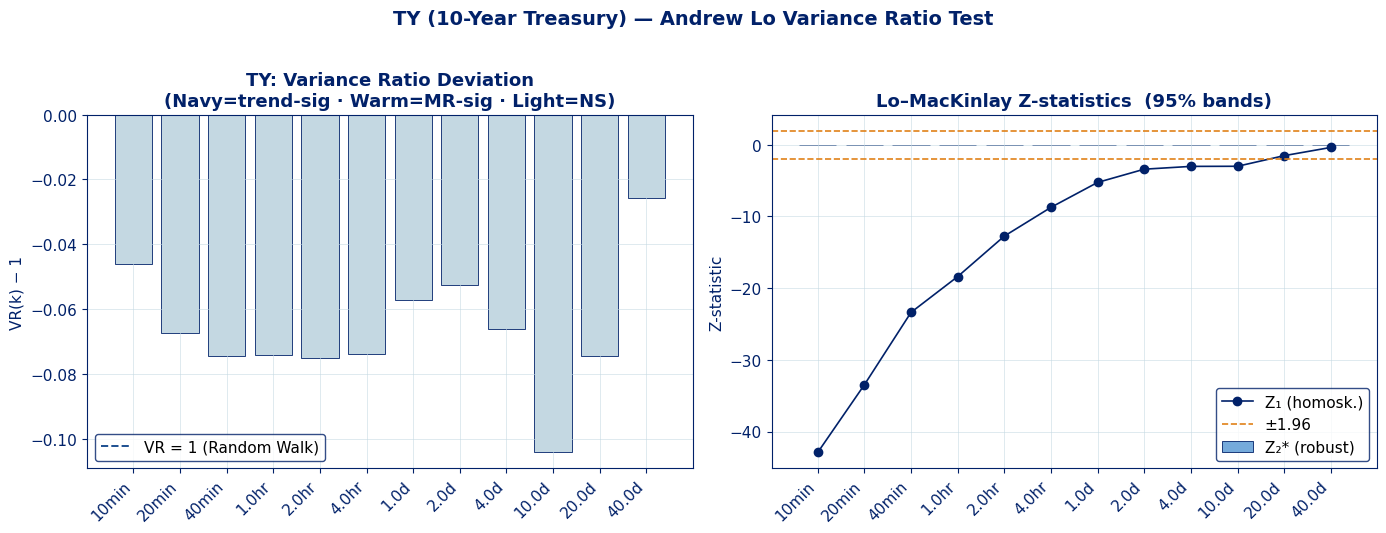

In [26]:
# ============================================================================
# VISUALIZE VR RESULTS (Columbia theme)
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# --- (a) VR(k) - 1 ---------------------------------------------------------
ax1 = axes[0]
bar_colors = []
for sig, vr in zip(vr_df['significant'], vr_df['VR']):
    if sig and vr > 1:        bar_colors.append(COLUMBIA_NAVY)      # sig trend
    elif sig and vr < 1:      bar_colors.append(COLUMBIA_WARM)      # sig mean-revert
    else:                     bar_colors.append(COLUMBIA_ACCENT)    # not significant

ax1.bar(range(len(vr_df)), vr_df['VR'] - 1, color=bar_colors,
        edgecolor=COLUMBIA_NAVY, linewidth=0.6)
ax1.axhline(0, color=COLUMBIA_DARK, linewidth=1.4, linestyle='--',
            label='VR = 1 (Random Walk)')
ax1.set_xticks(range(len(vr_df)))
ax1.set_xticklabels(vr_df['time_scale'], rotation=45, ha='right')
ax1.set_ylabel('VR(k) − 1')
ax1.set_title(f"{TICKER}: Variance Ratio Deviation\n"
              f"(Navy=trend-sig · Warm=MR-sig · Light=NS)")
ax1.legend(loc='best')

# --- (b) Z-statistics ------------------------------------------------------
ax2 = axes[1]
ax2.bar(range(len(vr_df)), vr_df['Z2_robust'], color=COLUMBIA_CORE,
        edgecolor=COLUMBIA_NAVY, linewidth=0.6, label='Z₂* (robust)')
ax2.plot(range(len(vr_df)), vr_df['Z1'],
         color=COLUMBIA_NAVY, marker='o', linewidth=1.2, label='Z₁ (homosk.)')
ax2.axhline( 1.96, color=COLUMBIA_WARM, linestyle='--', linewidth=1.2, label='±1.96')
ax2.axhline(-1.96, color=COLUMBIA_WARM, linestyle='--', linewidth=1.2)
ax2.set_xticks(range(len(vr_df)))
ax2.set_xticklabels(vr_df['time_scale'], rotation=45, ha='right')
ax2.set_ylabel('Z-statistic')
ax2.set_title('Lo–MacKinlay Z-statistics  (95% bands)')
ax2.legend(loc='best')

plt.suptitle(f"{TICKER} ({MARKET['name']}) — Andrew Lo Variance Ratio Test",
             fontsize=14, color=COLUMBIA_NAVY, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Push–Response Test

For each **push window** $p$ and **response window** $r$, compute the trailing return
$x_i = (P_{i+p} - P_i)/P_i$ and the forward return $y_i = (P_{i+p+r} - P_{i+p})/P_{i+p}$.
The regression $y = \alpha + \beta x + \varepsilon$ quantifies persistence:

- $\beta > 0$: pushes are followed by same-direction responses → **trend continuation**.
- $\beta < 0$: pushes are followed by opposite-direction responses → **mean reversion**.

We sweep a grid of $(p,r)$ pairs and aggregate the resulting $\beta$ surface.

In [27]:
@jit(nopython=True, cache=True)
def calc_push_response(prices, pw, rw):
    n = len(prices)
    total = pw + rw
    if n < total + 1:
        return np.array([0.0]), np.array([0.0])
    
    n_obs = n - total
    push_ret = np.zeros(n_obs)
    resp_ret = np.zeros(n_obs)
    
    for i in range(n_obs):
        if prices[i] > 0 and prices[i + pw] > 0:
            push_ret[i] = (prices[i + pw] - prices[i]) / prices[i]
            resp_ret[i] = (prices[i + total] - prices[i + pw]) / prices[i + pw]
    
    return push_ret, resp_ret


def push_response_test(prices, pw, rw):
    prices = np.asarray(prices, dtype=np.float64)
    push_ret, resp_ret = calc_push_response(prices, pw, rw)
    
    if len(push_ret) < 50:
        return {'error': True}
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(push_ret, resp_ret)
    
    return {
        'pw': pw, 'rw': rw,
        'beta': slope,
        'p_value': p_value,
        'correlation': np.corrcoef(push_ret, resp_ret)[0, 1],
        'significant': p_value < 0.05,
        'pattern': 'trend' if slope > 0 else 'mean_revert',
        'error': False
    }

In [28]:
# Run Push-Response tests
prices = df['Close'].values
windows = [6, 12, 24, 48, 78, 156, 312, 780]

print("Running Push-Response Tests...")
pr_results = []

for pw in tqdm(windows, desc="Push windows"):
    for rw in windows:
        result = push_response_test(prices, pw, rw)
        if not result.get('error', True):
            pr_results.append(result)

pr_df = pd.DataFrame(pr_results)
print(f"\nCompleted {len(pr_df)} tests")

Running Push-Response Tests...


Push windows:   0%|          | 0/8 [00:00<?, ?it/s]


Completed 64 tests


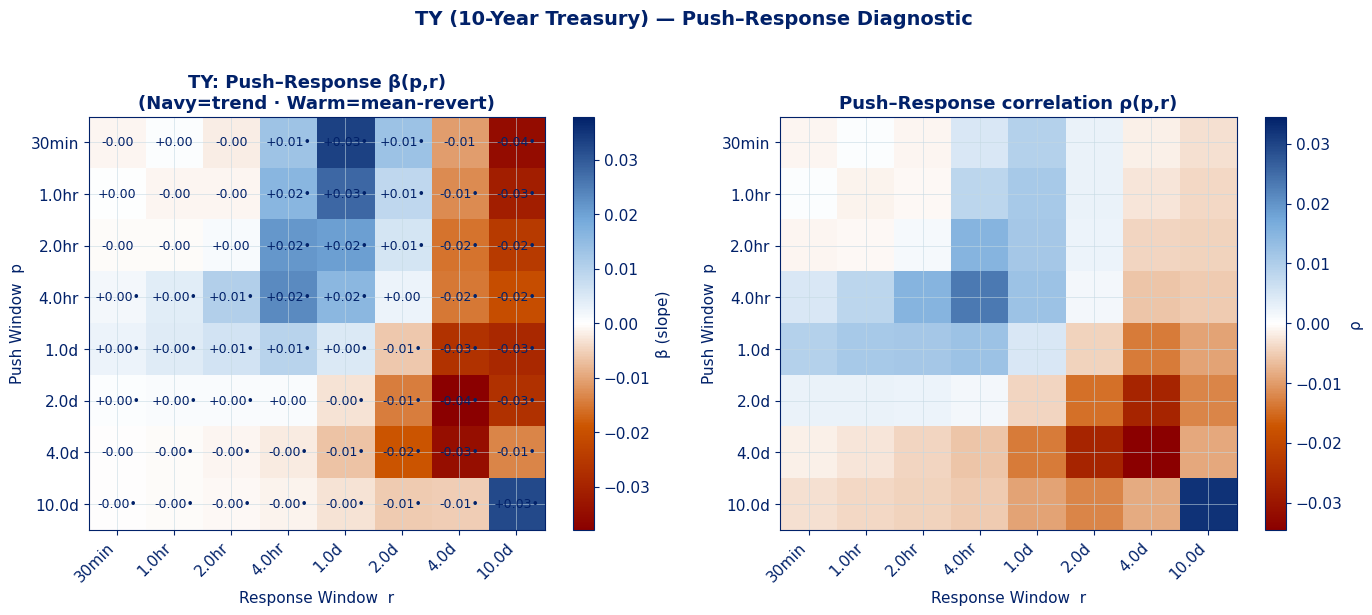

In [29]:
# ============================================================================
# VISUALIZE PUSH–RESPONSE (Columbia-themed heatmaps: beta + significance)
# ============================================================================
beta_pivot = pr_df.pivot(index='pw', columns='rw', values='beta')
corr_pivot = pr_df.pivot(index='pw', columns='rw', values='correlation')
# Note: pandas 2.1+ removed DataFrame.applymap — use a vectorised comparison instead.
sig_pivot = (pr_df.pivot(index='pw', columns='rw', values='p_value') < 0.05).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- (a) Beta heatmap -----------------------------------------------------
ax1 = axes[0]
vmax = max(abs(beta_pivot.values.min()), abs(beta_pivot.values.max()))
im1 = ax1.imshow(beta_pivot.values, cmap=COLUMBIA_DIVERGING,
                 aspect='auto', vmin=-vmax, vmax=vmax)
ax1.set_xticks(range(len(beta_pivot.columns)))
ax1.set_xticklabels([bars_to_time(c) for c in beta_pivot.columns], rotation=45, ha='right')
ax1.set_yticks(range(len(beta_pivot.index)))
ax1.set_yticklabels([bars_to_time(i) for i in beta_pivot.index])
ax1.set_xlabel('Response Window  r')
ax1.set_ylabel('Push Window  p')
ax1.set_title(f"{TICKER}: Push–Response β(p,r)\n(Navy=trend · Warm=mean-revert)")
# annotate with bold ring for significance
for i in range(len(beta_pivot.index)):
    for j in range(len(beta_pivot.columns)):
        val = beta_pivot.iloc[i, j]
        marker = '•' if sig_pivot.iloc[i, j] else ''
        ax1.text(j, i, f"{val:+.2f}{marker}", ha='center', va='center',
                 fontsize=9, color=COLUMBIA_NAVY)
plt.colorbar(im1, ax=ax1, label='β (slope)')

# --- (b) Correlation heatmap ---------------------------------------------
ax2 = axes[1]
cmax = max(abs(corr_pivot.values.min()), abs(corr_pivot.values.max()))
im2 = ax2.imshow(corr_pivot.values, cmap=COLUMBIA_DIVERGING,
                 aspect='auto', vmin=-cmax, vmax=cmax)
ax2.set_xticks(range(len(corr_pivot.columns)))
ax2.set_xticklabels([bars_to_time(c) for c in corr_pivot.columns], rotation=45, ha='right')
ax2.set_yticks(range(len(corr_pivot.index)))
ax2.set_yticklabels([bars_to_time(i) for i in corr_pivot.index])
ax2.set_xlabel('Response Window  r')
ax2.set_ylabel('Push Window  p')
ax2.set_title('Push–Response correlation ρ(p,r)')
plt.colorbar(im2, ax=ax2, label='ρ')

plt.suptitle(f"{TICKER} ({MARKET['name']}) — Push–Response Diagnostic",
             fontsize=14, color=COLUMBIA_NAVY, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Summary & Recommendation

In [30]:
print("\n" + "=" * 72)
print(f"MARKET INEFFICIENCY ANALYSIS: {MARKET['ticker']} ({MARKET['name']})")
print("=" * 72)

# --- VR summary ------------------------------------------------------------
vr_trend = vr_df[vr_df['significant'] & (vr_df['VR'] > 1)]
vr_mr    = vr_df[vr_df['significant'] & (vr_df['VR'] < 1)]

print("\n1. ANDREW LO VARIANCE RATIO (robust Z₂*):")
if len(vr_trend):
    print(f"   ▸ Significant TREND at: {', '.join(vr_trend['time_scale'])}")
if len(vr_mr):
    print(f"   ▸ Significant MEAN-REVERSION at: {', '.join(vr_mr['time_scale'])}")
if not len(vr_trend) and not len(vr_mr):
    print("   ▸ No rejections of the random-walk null at 5%")

# --- PR summary ------------------------------------------------------------
sig_pr = pr_df[pr_df['significant']]
pr_trend = int((sig_pr['pattern'] == 'trend').sum())
pr_mr    = int((sig_pr['pattern'] == 'mean_revert').sum())

print("\n2. PUSH–RESPONSE β:")
print(f"   ▸ Significant trend-continuation (β>0): {pr_trend}")
print(f"   ▸ Significant mean-reverting   (β<0):   {pr_mr}")
print(f"   ▸ Mean β across grid: {pr_df['beta'].mean():+.4f}")

# --- Recommendation --------------------------------------------------------
trend_score = len(vr_trend) + pr_trend
mr_score    = len(vr_mr)    + pr_mr

print("\n3. RECOMMENDATION:")
if trend_score > mr_score:
    print("   ✅ Evidence favors a TREND-FOLLOWING strategy (Channel WithDDControl).")
elif mr_score > trend_score:
    print("   ⚠️  Evidence favors mean-reversion; trend strategy may underperform.")
else:
    print("   ⚖️  Mixed evidence — proceed with Channel WithDDControl as baseline.")

print("=" * 72)


MARKET INEFFICIENCY ANALYSIS: TY (10-Year Treasury)

1. ANDREW LO VARIANCE RATIO (robust Z₂*):
   ▸ No rejections of the random-walk null at 5%

2. PUSH–RESPONSE β:
   ▸ Significant trend-continuation (β>0): 23
   ▸ Significant mean-reverting   (β<0):   28
   ▸ Mean β across grid: -0.0020

3. RECOMMENDATION:
   ⚠️  Evidence favors mean-reversion; trend strategy may underperform.


---
## Next: Notebook 02 - Strategy & Walk-Forward

**End of Notebook 01**